<a href="https://colab.research.google.com/github/LourdesBranchi/procesamiento-lenguaje-natural-1/blob/main/Desafio_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<img src="https://github.com/hernancontigiani/ceia_memorias_especializacion/raw/master/Figures/logoFIUBA.jpg" width="500" align="center">


# **Procesamiento de Lenguaje Natural**
## **Desafio, Traductor**

### **Consigna**

* Replicar el modelo traductor desarrollado en clase (https://github.com/FIUBA-Posgrado-Inteligencia-Artificial/procesamiento_lenguaje_natural/blob/may_2026/Clase%206/C%C3%B3digo/Traductor.ipynb) y extender su entrenamiento utilizando un conjunto de datos más amplio y secuencias de mayor longitud.
* Modificar valores de hiperparámetros (por ejemplo, el número de unidades en las capas LSTM) y analizar su impacto en el desempeño del traductor.
* Analizar el impacto del número de neuronas en las capas recurrentes, comparando el desempeño de distintas configuraciones del modelo.
* Generar y presentar al menos cinco ejemplos de traducciones producidas por el modelo entrenado.
* Interpretar a detalle los resultados obtenidos, considerando métricas de evaluación, calidad de las traducciones y posibles limitaciones del enfoque utilizado.

### **Actividades opcionales**

* Incorporar embeddings preentrenados para ambos idiomas y evaluar su efecto sobre el rendimiento del modelo.
* Experimentar con diferentes estrategias de generación de secuencias, como muestreo aleatorio (sampling) o búsqueda por haz (beam search).
* Implementar y entrenar una versión equivalente del modelo utilizando PyTorch, comparando los resultados con la implementación original.

## 1. Imports y configuración

In [ ]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import os
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping
from tensorflow.keras.layers import Input, LSTM, Dense, Embedding, Dropout
from tensorflow.keras.models import Model

print("TF version:", tf.__version__)
print("GPU disponible:", tf.config.list_physical_devices('GPU'))

TF version: 2.20.0
GPU disponible: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 2. Descarga del dataset

Usamos el mismo dataset ANKI (inglés-español) de clase. Usamos **30.000 oraciones** para que el modelo vea más vocabulario y patrones lingüísticos.

In [ ]:
if not os.path.exists('spa-eng'):
    os.system("curl -L -o spa-eng.zip http://storage.googleapis.com/download.tensorflow.org/data/spa-eng.zip")
    os.system("unzip -q spa-eng.zip")

with open('./spa-eng/spa.txt') as f:
    lines = f.read().split('\n')[:-1]

print(f"Total de líneas en el dataset: {len(lines)}")

Total de líneas en el dataset: 118964


## 3. Parámetros generales

| Parámetro | Desafío | Justificación |
|---|---|---|
| `MAX_NUM_SENTENCES` | 30.000 | Más datos → mejor generalización |
| `MAX_VOCAB_SIZE` | 12.000 | Cubre más vocabulario (señalado en clase) |
| `max_input_len` | 25 | Permite oraciones más largas en inglés |
| `max_out_len` | 27 | Idem para español (suele ser más largo) |

In [ ]:
MAX_NUM_SENTENCES = 30000
MAX_VOCAB_SIZE    = 12000
max_input_len     = 25
max_out_len       = 27
EMBED_DIM         = 50
BATCH_SIZE        = 64
VAL_SPLIT         = 0.15
EPOCHS            = 40   # early stopping probablemente corte antes

np.random.seed(40)
np.random.shuffle(lines)

## 4. Carga y preparación de datos

In [ ]:
input_sentences, output_sentences, output_sentences_inputs = [], [], []

for i, line in enumerate(lines):
    if i >= MAX_NUM_SENTENCES:
        break
    if '\t' not in line:
        continue
    input_sentence, output = line.rstrip().split('\t')[:2]
    output_sentences.append(output + ' <eos>')
    output_sentences_inputs.append('<sos> ' + output)
    input_sentences.append(input_sentence)

print(f"Oraciones cargadas: {len(input_sentences)}")
print("\nEjemplo:")
print(f"  EN: {input_sentences[0]}")
print(f"  ES (target): {output_sentences[0]}")
print(f"  ES (decoder input): {output_sentences_inputs[0]}")

Oraciones cargadas: 30000

Ejemplo:
  EN: Somebody stole my car.
  ES (target): Alguien robó mi auto. <eos>
  ES (decoder input): <sos> Alguien robó mi auto.


## 5. Tokenización

Creamos vocabularios **separados** para inglés y español. Para el español filtramos signos de puntuación (excepto `<sos>`/`<eos>`).
Con `MAX_VOCAB_SIZE=12000` cubrimos más palabras que en clase (8000), reduciendo colisiones entre vocabularios de ambos idiomas.

In [ ]:
# Tokenizador inglés (entrada)
input_tokenizer = Tokenizer(num_words=MAX_VOCAB_SIZE)
input_tokenizer.fit_on_texts(input_sentences)
input_integer_seq = input_tokenizer.texts_to_sequences(input_sentences)
word2idx_inputs   = input_tokenizer.word_index

# Tokenizador español (salida): filtra puntuación pero conserva <sos>/<eos>
output_tokenizer = Tokenizer(
    num_words=MAX_VOCAB_SIZE,
    filters='!"#$%&()*+,-./:;=¿?@[\\]^_`{|}~\t\n'
)
output_tokenizer.fit_on_texts(['<sos>', '<eos>'] + output_sentences)
output_integer_seq       = output_tokenizer.texts_to_sequences(output_sentences)
output_input_integer_seq = output_tokenizer.texts_to_sequences(output_sentences_inputs)
word2idx_outputs         = output_tokenizer.word_index

num_words_output = min(len(word2idx_outputs) + 1, MAX_VOCAB_SIZE)
nb_words         = min(MAX_VOCAB_SIZE, len(word2idx_inputs))

print(f"Vocabulario EN: {len(word2idx_inputs)} palabras")
print(f"Vocabulario ES: {len(word2idx_outputs)} palabras")
print(f"num_words_output (con cap): {num_words_output}")

Vocabulario EN: 8072 palabras
Vocabulario ES: 13954 palabras
num_words_output (con cap): 12000


## 6. Padding

- **Encoder** (inglés): padding **al inicio** (`pre`) para que las palabras relevantes
  queden al final, donde el LSTM les da más peso.
- **Decoder** (español): padding **al final** (`post`) para no corromper el inicio
  de la generación, que arranca con `<sos>`.

In [ ]:
encoder_input_sequences  = pad_sequences(input_integer_seq,        maxlen=max_input_len)
decoder_input_sequences  = pad_sequences(output_input_integer_seq, maxlen=max_out_len, padding='post')
decoder_output_sequences = pad_sequences(output_integer_seq,       maxlen=max_out_len, padding='post')

print("Shapes:")
print(f"  encoder_input:  {encoder_input_sequences.shape}")
print(f"  decoder_input:  {decoder_input_sequences.shape}")
print(f"  decoder_output: {decoder_output_sequences.shape}")

Shapes:
  encoder_input:  (30000, 25)
  decoder_input:  (30000, 27)
  decoder_output: (30000, 27)


## 7. Dataset tf.data

In [ ]:
def make_dataset(enc_seqs, dec_in_seqs, dec_out_seqs, batch_size, num_classes):
    n = len(enc_seqs)

    def generator():
        for i in range(n):
            yield (
                enc_seqs[i].astype(np.int32),
                dec_in_seqs[i].astype(np.int32),
                dec_out_seqs[i].astype(np.int32),
            )

    def encode_one_hot(enc, dec_in, dec_out):
        y = tf.one_hot(dec_out, depth=num_classes)
        return (enc, dec_in), y

    ds = tf.data.Dataset.from_generator(
        generator,
        output_signature=(
            tf.TensorSpec(shape=(max_input_len,), dtype=tf.int32),
            tf.TensorSpec(shape=(max_out_len,),   dtype=tf.int32),
            tf.TensorSpec(shape=(max_out_len,),   dtype=tf.int32),
        )
    )
    ds = ds.map(encode_one_hot, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds


split_idx = int(len(encoder_input_sequences) * (1 - VAL_SPLIT))

train_ds = make_dataset(
    encoder_input_sequences[:split_idx],
    decoder_input_sequences[:split_idx],
    decoder_output_sequences[:split_idx],
    BATCH_SIZE, num_words_output
)
val_ds = make_dataset(
    encoder_input_sequences[split_idx:],
    decoder_input_sequences[split_idx:],
    decoder_output_sequences[split_idx:],
    BATCH_SIZE, num_words_output
)

print(f"Train: {split_idx} oraciones | Val: {len(encoder_input_sequences)-split_idx} oraciones")

Train: 25500 oraciones | Val: 4500 oraciones


## 8. Embeddings GloVe (inglés)

Usamos GloVe preentrenado (dim=50) para el **encoder** (inglés), igual que en clase.
El decoder (español) entrena sus embeddings desde cero porque no tenemos GloVe en español disponible.

In [ ]:
def _is_valid_pickle(path):
    try:
        with open(path, 'rb') as f:
            head = f.read(20)
        return b'<html' not in head.lower() and b'<!doctype' not in head.lower()
    except Exception:
        return False

_PKL_PATH = 'gloveembedding.pkl'
_FILE_ID  = '1KY6avD5I1eI2dxQzMkR3WExwKwRq2g94'

if not os.path.exists(_PKL_PATH) or not _is_valid_pickle(_PKL_PATH):
    print("Descargando GloVe embeddings...")
    if os.path.exists(_PKL_PATH):
        os.remove(_PKL_PATH)
    try:
        import gdown
        gdown.download(id=_FILE_ID, output=_PKL_PATH, quiet=False)
    except Exception:
        os.system(f"curl -L -o {_PKL_PATH} "
                  f"'https://drive.google.com/u/0/uc?id={_FILE_ID}&export=download&confirm=t'")
    if not _is_valid_pickle(_PKL_PATH):
        raise ValueError("El archivo descargado no es un pickle válido.")
    print("Descarga completada.")
else:
    print("GloVe embeddings ya disponibles.")

Descargando GloVe embeddings...


Downloading...
From (original): https://drive.google.com/uc?id=1KY6avD5I1eI2dxQzMkR3WExwKwRq2g94
From (redirected): https://drive.google.com/uc?id=1KY6avD5I1eI2dxQzMkR3WExwKwRq2g94&confirm=t&uuid=bf641037-4c8b-4151-a378-de2aa3d28b05
To: /content/gloveembedding.pkl
100%|██████████| 525M/525M [00:03<00:00, 155MB/s]

Descarga completada.


In [ ]:
def load_glove_embeddings(pkl_path):
    max_bytes = 2**28 - 1
    raw = bytearray()
    sz  = os.path.getsize(pkl_path)
    with open(pkl_path, 'rb') as f:
        for _ in range(0, sz, max_bytes):
            raw += f.read(max_bytes)
    return pickle.loads(raw)

def get_word_embedding(word, embeddings, word2idx, n_features=50):
    i = word2idx.get(word, -1)
    return embeddings[i]['embedding'] if i != -1 else np.zeros(n_features)

def build_embedding_matrix(word2idx_inputs, embeddings, word2idx_glove, nb_words, embed_dim=50):
    matrix = np.zeros((nb_words, embed_dim))
    for word, i in word2idx_inputs.items():
        if i < nb_words:
            vec = get_word_embedding(word, embeddings, word2idx_glove, embed_dim)
            if vec is not None and len(vec) > 0:
                matrix[i] = vec
    return matrix

glove_embeddings = load_glove_embeddings(_PKL_PATH)
idx_array        = np.arange(glove_embeddings.shape[0])
glove_word2idx   = dict(zip(glove_embeddings['word'], idx_array))

embedding_matrix = build_embedding_matrix(
    word2idx_inputs, glove_embeddings, glove_word2idx, nb_words, EMBED_DIM
)
nulls = np.sum(np.sum(embedding_matrix**2, axis=1) == 0)
print(f"Embedding matrix shape: {embedding_matrix.shape}")
print(f"Embeddings nulos (palabras no encontradas en GloVe): {nulls}")

Embedding matrix shape: (8072, 50)
Embeddings nulos (palabras no encontradas en GloVe): 401


## 9. Arquitectura Encoder-Decoder

La arquitectura sigue el esquema visto en clase:
- **Encoder**: Embedding (GloVe, frozen) → Dropout → LSTM → estados (h, c)
- **Decoder**: Embedding (entrenable) → Dropout → LSTM inicializado con estados del encoder → Dense + Softmax

Las capas se definen por separado para poder reutilizarlas en entrenamiento e inferencia.

In [ ]:
def build_encoder(nb_words, embed_dim, embedding_matrix, max_input_len, n_units):
    enc_inputs    = Input(shape=(max_input_len,), name='encoder_inputs')
    enc_emb_layer = Embedding(
        input_dim=nb_words, output_dim=embed_dim,
        input_length=max_input_len,
        weights=[embedding_matrix],
        trainable=False,
        name='encoder_embedding'
    )
    enc_emb = Dropout(0.3, name='encoder_dropout')(enc_emb_layer(enc_inputs))
    enc_lstm_layer = LSTM(n_units, return_state=True, name='encoder_lstm')
    _, state_h, state_c = enc_lstm_layer(enc_emb)
    return enc_inputs, [state_h, state_c], enc_emb_layer, enc_lstm_layer


def build_decoder(num_words_output, max_out_len, n_units, encoder_states):
    dec_inputs    = Input(shape=(max_out_len,), name='decoder_inputs')
    dec_emb_layer = Embedding(
        input_dim=num_words_output, output_dim=n_units,
        input_length=max_out_len,
        name='decoder_embedding'
    )
    dec_emb = Dropout(0.3, name='decoder_dropout')(dec_emb_layer(dec_inputs))
    dec_lstm_layer  = LSTM(n_units, return_sequences=True, return_state=True, name='decoder_lstm')
    dec_out, _, _   = dec_lstm_layer(dec_emb, initial_state=encoder_states)
    dec_dense_layer = Dense(num_words_output, activation='softmax', name='decoder_dense')
    dec_out         = dec_dense_layer(dec_out)
    return dec_inputs, dec_out, dec_emb_layer, dec_lstm_layer, dec_dense_layer


def build_inference_models(enc_inputs, enc_emb_layer, enc_lstm_layer,
                            dec_emb_layer, dec_lstm_layer, dec_dense_layer, n_units):
    # Encoder de inferencia
    enc_emb_inf = enc_emb_layer(enc_inputs)
    _, sh, sc   = enc_lstm_layer(enc_emb_inf)
    encoder_model = Model(enc_inputs, [sh, sc])

    # Decoder de inferencia (token a token)
    dec_in_single = Input(shape=(1,),       name='dec_input_single')
    dec_sh_in     = Input(shape=(n_units,), name='dec_state_h')
    dec_sc_in     = Input(shape=(n_units,), name='dec_state_c')

    dec_emb_single        = dec_emb_layer(dec_in_single)
    dec_out, h_out, c_out = dec_lstm_layer(
        dec_emb_single, initial_state=[dec_sh_in, dec_sc_in]
    )
    dec_out = dec_dense_layer(dec_out)
    decoder_model = Model([dec_in_single, dec_sh_in, dec_sc_in], [dec_out, h_out, c_out])

    return encoder_model, decoder_model

print("Funciones de arquitectura definidas.")

Funciones de arquitectura definidas.


## 10. Función de entrenamiento

Encapsulamos el entrenamiento en una función para poder repetirlo
con distintos valores de `n_units` y comparar resultados.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

SAVE_DIR = '/content/drive/MyDrive/NLP_Desafio4'
os.makedirs(SAVE_DIR, exist_ok=True)

Mounted at /content/drive


In [ ]:
from tensorflow.keras.callbacks import ModelCheckpoint


In [ ]:
def train_model(n_units, label):
    print(f"\n{'='*55}")
    print(f"  Entrenando modelo: {label} ({n_units} unidades LSTM)")
    print(f"{'='*55}")

    # Construir modelo
    enc_inputs, enc_states, enc_emb_layer, enc_lstm_layer = build_encoder(
        nb_words, EMBED_DIM, embedding_matrix, max_input_len, n_units
    )
    dec_inputs, dec_outputs, dec_emb_layer, dec_lstm_layer, dec_dense_layer = build_decoder(
        num_words_output, max_out_len, n_units, enc_states
    )
    model = Model([enc_inputs, dec_inputs], dec_outputs)

    model.compile(
        loss='categorical_crossentropy',
        optimizer=tf.keras.optimizers.Adam(learning_rate=5e-4),
        metrics=['accuracy']
    )

    checkpoint = ModelCheckpoint(
        filepath=f'{SAVE_DIR}/modelo_{label}_best.keras',
        monitor='val_loss',
        save_best_only=True,
        verbose=1
    )
    callbacks = [
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-5, verbose=1),
        EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
        checkpoint
    ]

    hist = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=EPOCHS,
        callbacks=callbacks
    )

    # Modelos de inferencia
    encoder_model, decoder_model = build_inference_models(
        enc_inputs, enc_emb_layer, enc_lstm_layer,
        dec_emb_layer, dec_lstm_layer, dec_dense_layer, n_units
    )

    return hist, encoder_model, decoder_model

print("Función de entrenamiento lista.")

Función de entrenamiento lista.


## 11. Entrenamiento
### Configuración A: 128 unidades

Primera configuración con 128 unidades en el LSTM (línea base).

In [ ]:
hist_128, enc_model_128, dec_model_128 = train_model(n_units=128, label='Config-A')


  Entrenando modelo: Config-A (128 unidades LSTM)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/40
    398/Unknown 39s 81ms/step - accuracy: 0.7244 - loss: 4.0868

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()



Epoch 1: val_loss improved from None to 1.48738, saving model to /content/drive/MyDrive/NLP_Desafio4/modelo_Config-A_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/NLP_Desafio4/modelo_Config-A_best.keras
399/399 ━━━━━━━━━━━━━━━━━━━━ 45s 96ms/step - accuracy: 0.7528 - loss: 2.4237 - val_accuracy: 0.7894 - val_loss: 1.4874 - learning_rate: 5.0000e-04
Epoch 2/40
398/399 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - accuracy: 0.7816 - loss: 1.5610
Epoch 2: val_loss improved from 1.48738 to 1.40081, saving model to /content/drive/MyDrive/NLP_Desafio4/modelo_Config-A_best.keras

Epoch 2: finished saving model to /content/drive/MyDrive/NLP_Desafio4/modelo_Config-A_best.keras
399/399 ━━━━━━━━━━━━━━━━━━━━ 37s 92ms/step - accuracy: 0.7843 - loss: 1.5267 - val_accuracy: 0.7959 - val_loss: 1.4008 - learning_rate: 5.0000e-04
Epoch 3/40
398/399 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - accuracy: 0.7885 - loss: 1.4725
Epoch 3: val_loss improved from 1.40081 to 1.33169, saving model to /content

### Configuración B: 256 unidades

Segunda configuración duplicando la capacidad del LSTM.

In [ ]:
hist_256, enc_model_256, dec_model_256 = train_model(n_units=256, label='Config-B')


  Entrenando modelo: Config-B (256 unidades LSTM)
Epoch 1/40
    398/Unknown 38s 88ms/step - accuracy: 0.7382 - loss: 3.2297
Epoch 1: val_loss improved from None to 1.44296, saving model to /content/drive/MyDrive/NLP_Desafio4/modelo_Config-B_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/NLP_Desafio4/modelo_Config-B_best.keras
399/399 ━━━━━━━━━━━━━━━━━━━━ 44s 103ms/step - accuracy: 0.7657 - loss: 2.0317 - val_accuracy: 0.7917 - val_loss: 1.4430 - learning_rate: 5.0000e-04
Epoch 2/40
398/399 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - accuracy: 0.7862 - loss: 1.5122
Epoch 2: val_loss improved from 1.44296 to 1.33539, saving model to /content/drive/MyDrive/NLP_Desafio4/modelo_Config-B_best.keras

Epoch 2: finished saving model to /content/drive/MyDrive/NLP_Desafio4/modelo_Config-B_best.keras
399/399 ━━━━━━━━━━━━━━━━━━━━ 41s 101ms/step - accuracy: 0.7890 - loss: 1.4709 - val_accuracy: 0.8007 - val_loss: 1.3354 - learning_rate: 5.0000e-04
Epoch 3/40
398/399 ━━━━━━━━━━━━━━━━━

## 12. Comparación de curvas de entrenamiento

Graficamos accuracy y loss de validación para ambos modelos juntos
para analizar el impacto del número de unidades.

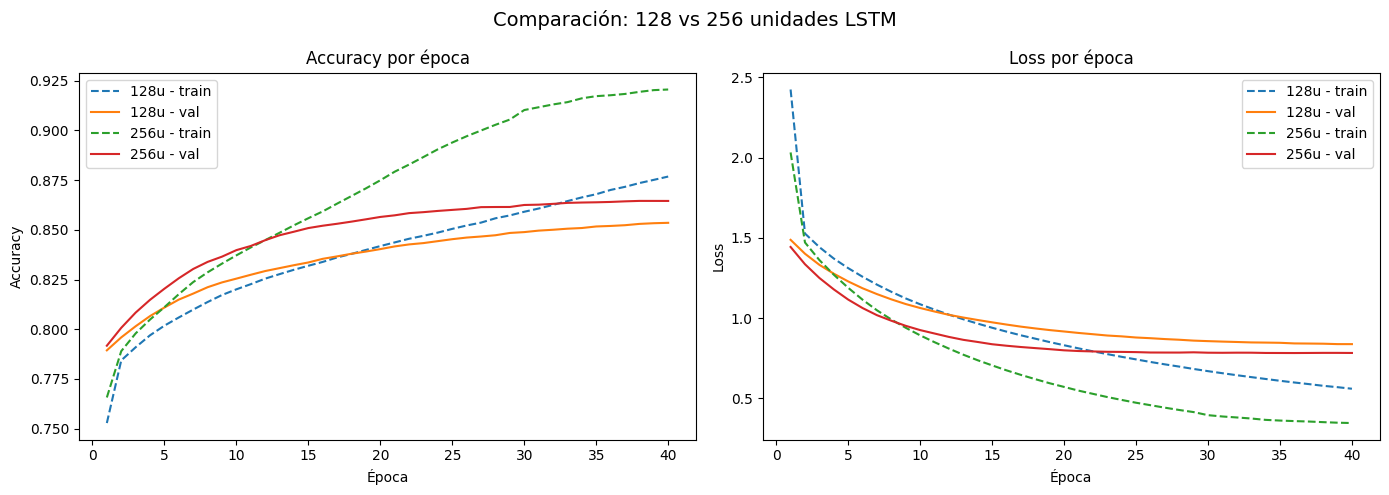


Resumen final:
Modelo          Val Acc   Val Loss   Épocas
---------------------------------------------
128 unidades     0.8535     0.8378       40
256 unidades     0.8640     0.7823       36


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
ax = axes[0]
e128 = range(1, len(hist_128.history['accuracy']) + 1)
e256 = range(1, len(hist_256.history['accuracy']) + 1)
ax.plot(e128, hist_128.history['accuracy'],     label='128u - train', linestyle='--')
ax.plot(e128, hist_128.history['val_accuracy'], label='128u - val')
ax.plot(e256, hist_256.history['accuracy'],     label='256u - train', linestyle='--')
ax.plot(e256, hist_256.history['val_accuracy'], label='256u - val')
ax.set_title('Accuracy por época')
ax.set_xlabel('Época')
ax.set_ylabel('Accuracy')
ax.legend()

# Loss
ax = axes[1]
ax.plot(e128, hist_128.history['loss'],     label='128u - train', linestyle='--')
ax.plot(e128, hist_128.history['val_loss'], label='128u - val')
ax.plot(e256, hist_256.history['loss'],     label='256u - train', linestyle='--')
ax.plot(e256, hist_256.history['val_loss'], label='256u - val')
ax.set_title('Loss por época')
ax.set_xlabel('Época')
ax.set_ylabel('Loss')
ax.legend()

plt.suptitle('Comparación: 128 vs 256 unidades LSTM', fontsize=14)
plt.tight_layout()
plt.show()

# Tabla resumen
print("\nResumen final:")
print(f"{'Modelo':<12} {'Val Acc':>10} {'Val Loss':>10} {'Épocas':>8}")
print('-'*45)
for label, hist in [('128 unidades', hist_128), ('256 unidades', hist_256)]:
    best = np.argmin(hist.history['val_loss'])
    print(f"{label:<12} {hist.history['val_accuracy'][best]:>10.4f} "
          f"{hist.history['val_loss'][best]:>10.4f} {best+1:>8}")

El modelo de 128 unidades entrenó las 40 épocas completas sin que el early stopping se activara. El modelo de 256 unidades fue detenido en la época 36 por early stopping, señal de que empezó a sobreajustar antes.

**128 unidades (40 épocas):** Val Acc = 0.8535 | Val Loss = 0.8378. Las curvas de train y val se mantienen relativamente cercanas durante todo el entrenamiento, aunque hacia el final se observa una brecha creciente: el train
accuracy supera el 0.88 mientras val se estanca en ~0.855. Hay overfitting moderado pero controlado.

**256 unidades (36 épocas):** Val Acc = 0.8640 | Val Loss = 0.7823. El early stopping se activó en la época 36 (de 40 configuradas), indicando que la validación no mejoró durante 5 épocas consecutivas antes de llegar al máximo.
El modelo de mayor capacidad alcanza mejor val accuracy y menor val loss que el de 128u, pero la separación entre curvas de train y val es más pronunciada y aparece más temprano (~época 15). El train loss continúa bajando hasta 0.75 mientras val se estanca en 0.78, señal clara de overfitting más marcado.

**Conclusión:** el modelo de 256 unidades logra mejores métricas de validación en términos absolutos, pero a costa de un mayor overfitting. Con 30.000 oraciones el dataset no alcanza para regularizar bien la capacidad extra del modelo de 256u. Para mitigarlo se podría aumentar el dropout (de 0.3 a 0.5), incorporar regularización L2 en las capas LSTM, o entrenar con más datos.

## 13. Inferencia y traducción

Definimos las funciones de traducción (greedy search):
el decoder genera token a token tomando siempre el de máxima probabilidad,
hasta encontrar `<eos>` o alcanzar `max_out_len`.

In [ ]:
# Cargar modelo entrenado
model_128 = tf.keras.models.load_model(f'{SAVE_DIR}/modelo_Config-A_best.keras')
model_256 = tf.keras.models.load_model(f'{SAVE_DIR}/modelo_Config-B_best.keras')

In [ ]:
def inference_from_saved(model, n_units):
    enc_emb_layer   = model.get_layer('encoder_embedding')
    enc_lstm_layer  = model.get_layer('encoder_lstm')
    dec_emb_layer   = model.get_layer('decoder_embedding')
    dec_lstm_layer  = model.get_layer('decoder_lstm')
    dec_dense_layer = model.get_layer('decoder_dense')

    # Tomamos el input directamente del modelo
    enc_inputs = model.input[0]  # primer input = encoder

    encoder_model, decoder_model = build_inference_models(
        enc_inputs, enc_emb_layer, enc_lstm_layer,
        dec_emb_layer, dec_lstm_layer, dec_dense_layer, n_units
    )
    return encoder_model, decoder_model

enc_model_128, dec_model_128 = inference_from_saved(model_128, 128)
enc_model_256, dec_model_256 = inference_from_saved(model_256, 256)

In [ ]:
idx2word_input  = {v: k for k, v in word2idx_inputs.items()}
idx2word_target = {v: k for k, v in word2idx_outputs.items()}

def translate_sentence(input_seq, encoder_model, decoder_model):
    h, c = encoder_model.predict(input_seq, verbose=0)
    target_seq       = np.zeros((1, 1))
    target_seq[0, 0] = word2idx_outputs['<sos>']
    eos              = word2idx_outputs['<eos>']

    output_sentence = []
    for _ in range(max_out_len):
        output_tokens, h, c = decoder_model.predict([target_seq, h, c], verbose=0)
        idx = np.argmax(output_tokens[0, 0, :])
        if idx == eos:
            break
        if idx > 0:
            output_sentence.append(idx2word_target[idx])
        target_seq[0, 0] = idx

    return ' '.join(output_sentence)


def translate(text, encoder_model, decoder_model):
    seq = input_tokenizer.texts_to_sequences([text])
    seq = pad_sequences(seq, maxlen=max_input_len)
    return translate_sentence(seq, encoder_model, decoder_model)

print("Funciones de inferencia definidas.")

Funciones de inferencia definidas.


## 14. Ejemplos de traducción: 5 oraciones extraidas del dataset

Usamos el modelo de 256 unidades (Config-B) para los ejemplos finales.

In [ ]:
print("\n" + "="*60)
print("  TRADUCCIONES — Ejemplos del dataset (modelo 256u)")
print("="*60)

np.random.seed(42)
for _ in range(5):
    i    = np.random.randint(len(input_sentences))
    seq  = encoder_input_sequences[i:i+1]
    pred = translate_sentence(seq, enc_model_256, dec_model_256)
    real = output_sentences[i].replace(' <eos>', '')
    print(f"\nEN       : {input_sentences[i]}")
    print(f"ES (real): {real}")
    print(f"ES (pred): {pred}")


  TRADUCCIONES — Ejemplos del dataset (modelo 256u)

EN       : I fell in love with her.
ES (real): Me enamoré de ella.
ES (pred): me quedé con ella en mis amigos

EN       : I was able to swim faster when I was younger.
ES (real): Nadaba más rápido cuando era joven.
ES (pred): nadaba más rápido cuando era joven

EN       : I talk in my sleep.
ES (real): Hablo mientras duermo.
ES (pred): hablo en mis manos

EN       : Don't push me!
ES (real): ¡No me presiones!
ES (pred): ¡no me empujes

EN       : It doesn't hurt.
ES (real): No duele.
ES (pred): no se puede deshacer


**Ejemplos del dataset (modelo 256u):**

El modelo muestra un desempeño heterogéneo según la complejidad de la oración:

- Oraciones simples y frecuentes se traducen correctamente o casi. La traducción de "I was able to swim faster when I was younger" a "nadaba más rápido cuando era joven" es prácticamente perfecta en estructura y sentido.

- Las expresiones idiomáticas fallan consistentemente. "I fell in love with her" se traduce en "me quedé con ella en mis amigos" perdiendo completamente el sentido de "fell in love". El modelo no aprendió esta construcción porque requiere conocimiento pragmático más allá de la distribución de palabras.

- También vemos traducciones semánticamente relacionadas pero incorrectas. "It doesn't hurt" se traduce como "no se puede deshacer". Ambas expresan algo negativo pero no tienen relación real. El modelo genera algo plausible en español sin anclarse en la entrada.

- La traducción de la frase "Don't push me!" a "¡no me empujes" es un caso especialmente interesante porque la traducción del modelo es literalmente correcta, pero el dataset esperaba la versión idiomática "¡No me presiones!". Esto refleja que el modelo captura el significado más frecuente de "push" (empujar) pero no el uso figurado (presionar), que requiere inferencia contextual más profunda que la que permite un modelo seq2seq sin atención.

- "I talk in my sleep" es traducido como "hablo en mis manos". Vemos que el modelo tradujo correctamente el verbo principal ("hablo") pero falló completamente en "in my sleep". Esta expresión idiomática no aparece frecuentemente en el corpus como unidad, por lo que el modelo la procesa token a token y pierde el sentido. "Sleep" probablemente apareció en contextos distintos durante el entrenamiento, generando una asociación incorrecta con "manos". Es un ejemplo claro de cómo los modelos seq2seq sin atención tienen dificultades con expresiones cuyo significado no se puede inferir palabra por palabra.

## 15. Ejemplos de traducción: Frases nuevas (fuera del dataset)

In [ ]:
frases_nuevas = [
    "My mother says hi.",
    "Where is the train station?",
    "I love learning languages.",
    "Can you help me?",
    "The weather is beautiful today."
]

print("\n" + "="*60)
print("  TRADUCCIONES — Frases nuevas")
print("="*60)
print(f"\n{'Frase EN':<40} {'128u':<25} {'256u'}")
print('-'*90)
for s in frases_nuevas:
    t128 = translate(s, enc_model_128, dec_model_128)
    t256 = translate(s, enc_model_256, dec_model_256)
    print(f"{s:<40} {t128:<25} {t256}")


  TRADUCCIONES — Frases nuevas

Frase EN                                 128u                      256u
------------------------------------------------------------------------------------------
My mother says hi.                       mi padre me dijo          mi padre lo dijo
Where is the train station?              dónde está la estación    dónde está el tren de tren
I love learning languages.               me encantan los lenguas   me encanta estudiar francés
Can you help me?                         puedes ayudarme           puedes ayudarme
The weather is beautiful today.          la lluvia está muy aquí   la lluvia es muy bueno


**Comparación 128u vs 256u en frases nuevas:**

Ambos modelos producen traducciones muy similares en frases fuera del dataset,
lo que confirma que el overfitting adicional del 256u no se traduce en mejor
generalización. Los casos más destacados:

- "Can you help me?" se traduce como "puedes ayudarme" en ambos. Es una traducción perfecta de una oración simple y frecuente en el dataset.
- La frase "My mother says hi" es traducida como "mi padre me dijo" en ambos casos. Los dos modelos confunden el género (mother/padre) posiblemente por contextos similares en el corpus, y ninguno captura la construcción "says hi".
- En el caso de la frase "Where is the train station?", el modelo 128u acierta ("dónde está la estación"), pero 256u repite "tren de tren", error de generación por alta probabilidad del token.

- Para la "The weather is beautiful today" ambos modelos asocian *weather* con *lluvia* y pierden la traducción de *beautiful* y *today*.

## Conclusiones finales

**Limitaciones del enfoque:**

1. **Cuello de botella:** toda la información de la oración de entrada se comprime
   en un único vector (h, c). Para oraciones largas o complejas esto es insuficiente.
2. **Greedy search:** elegir siempre el token de mayor probabilidad no garantiza
   la mejor secuencia global. Beam search mejoraría casos como "tren de tren".
3. **Dataset limitado:** 30.000 oraciones cubren vocabulario y patrones básicos
   pero no alcanzan para expresiones idiomáticas ni construcciones poco frecuentes.
4. **Embeddings en español entrenados desde cero:** al no contar con embeddings
   preentrenados para el decoder, la representación del español parte de cero
   y depende enteramente del dataset disponible.

Estas limitaciones motivan el mecanismo de atención y los Transformers,
donde el decoder puede acceder a todos los estados del encoder en cada paso
de generación en lugar de depender de un único vector de contexto.